In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm

In [ ]:
# higher S0 for call --> further ITM (or less OTM). higher S0 for put --> further OTM (or less ITM).
# higher K for call --> have to buy asset for more. higher K for put --> get to sell asset for more.
# higher vol --> more chance for further in the money positions, while downside payoff remains exactly same at 0.
# higher T for call (r +ve) --> strike cheaper as more time for discounting. higher T for put (r +ve) --> strike less valuable to sell for.
# higher r on a call --> K is worth less when discounted to present, so paying K at maturity is "cheaper" than paying K now.

# delta for call --> deep ITM delta approaches 1, as essentially guaranteed to realise the profit of ~$1 as spot increases by $1.
#                    ATM delta is generally above but not far off 0.5 (if r > 0), as there's roughly a 50% chance of ending up in the money.
#                    deep OTM delta approaches 0, as essentially no chance of exercising the option, regardless of small movements in spot.

# gamma for call --> deep ITM gamma approcaches 0, as delta is asymptotically approaching 1, so is flattening off.
#                    ATM gamma is roughly at its highest, as changes in spot are leading to big changes in delta.
#                    deep OTM gamma approcaches 0, as delta is asymptotically approaching 0, so is flattening off.

# vega for call --> deep ITM vega approaches 0, as the upside and downside of increasing volatility is really the same, so no benefit or loss.
#                   ATM vega is roughly at its highest, as this is where the ~zero downside, but potential upside is increased by volatility.
#                   deep OTM vega approaches 0, as small changes in volatility will not have much impact on bringin the option back ITM.

In [295]:
def black_scholes(call:bool, S0:float, K:float, vol:float, T:float, r:float):

    d1 = (np.log(S0 / K) + (r + vol**2 / 2) * T) / (vol * np.sqrt(T))
    d2 = d1 - (vol * np.sqrt(T))

    if call:
        price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        intrinsic_value = max(S0 - K, 0)

        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S0 * vol * np.sqrt(T))
        vega = 0.01 * S0 * norm.pdf(d1) * np.sqrt(T)

    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
        intrinsic_value = max(K - S0, 0)

        delta = norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S0 * vol * np.sqrt(T))
        vega = 0.01 * S0 * norm.pdf(d1) * np.sqrt(T)

    return price, delta, gamma, vega

In [296]:
S0 = 100
K = 100
vol = 0.2
T = 1
r = 0.05

price, delta, gamma, vega = black_scholes(call=True, S0=S0, K=K, vol=vol, T=T, r=r)

print(f"delta = {round(delta, 4)}")
print(f"gamma = {round(gamma, 4)}")
print(f"vega = {round(vega, 4)}")

delta = 0.6368
gamma = 0.0188
vega = 0.3752


In [144]:
def plot_price(call:bool, K:float, vol:float, T:float, r:float):
    if call:
        type = "Call"
    else:
        type = "Put"

    spot_lower, spot_upper = K * 0.5, K * 1.5

    gap = 1
    spots = np.arange(spot_lower, spot_upper + gap, gap)
    prices = []

    for S in spots:
        prices.append(black_scholes(call=call, S0=S, K=K, vol=vol, T=T, r=r)[0])

    plt.figure()
    plt.title(f"Option price vs Spot ({type})")
    plt.xlabel("Spot price")
    plt.ylabel("Option price")
    plt.plot(spots, prices)
    plt.show()

def plot_delta(call:bool, K:float, vol:float, T:float, r:float):
    if call:
        type = "Call"
    else:
        type = "Put"

    spot_lower, spot_upper = K * 0.5, K * 1.5

    gap = 1
    spots = np.arange(spot_lower, spot_upper + gap, gap)
    deltas = []

    for S in spots:
        deltas.append(black_scholes(call=call, S0=S, K=K, vol=vol, T=T, r=r)[2])

    plt.figure()
    plt.title(f"Delta vs Spot ({type})")
    plt.xlabel("Spot price")
    plt.ylabel("Delta")
    plt.plot(spots, deltas)
    plt.show()

def plot_gamma(call:bool, K:float, vol:float, T:float, r:float):
    if call:
        type = "Call"
    else:
        type = "Put"

    spot_lower, spot_upper = K * 0.5, K * 1.5

    gap = 1
    spots = np.arange(spot_lower, spot_upper + gap, gap)
    gammas = []

    for S in spots:
        gammas.append(black_scholes(call=call, S0=S, K=K, vol=vol, T=T, r=r)[3])

    plt.figure()
    plt.title(f"Gamma vs Spot ({type})")
    plt.xlabel("Spot price")
    plt.ylabel("Gamma")
    plt.plot(spots, gammas)
    plt.show()

def plot_vega(call:bool, K:float, vol:float, T:float, r:float):
    if call:
        type = "Call"
    else:
        type = "Put"

    spot_lower, spot_upper = K * 0.5, K * 1.5

    gap = 1
    spots = np.arange(spot_lower, spot_upper + gap, gap)
    vegas = []

    for S in spots:
        vegas.append(black_scholes(call=call, S0=S, K=K, vol=vol, T=T, r=r)[4])

    plt.figure()
    plt.title(f"Vega vs Spot ({type})")
    plt.xlabel("Spot price")
    plt.ylabel("Vega")
    plt.plot(spots, vegas)
    plt.show()


In [195]:
def plot_payoff(call:bool, K:float):
    if call:
        type = "Call"
    else:
        type = "Put"

    spot_lower, spot_upper = K * 0.5, K * 1.5

    gap = 0.1
    spots = np.arange(spot_lower, spot_upper + gap, gap)
    payoffs = []

    for S in spots:
        payoff = call * max(S - K, 0) + (not call) * max(K - S, 0)
        payoffs.append(payoff)

    plt.figure()
    plt.title(f"Option payoff vs Spot ({type})")
    plt.xlabel("Spot price")
    plt.ylabel("Payoff")
    plt.plot(spots, payoffs, color="green")
    plt.hlines(0, spot_lower, spot_upper, linestyles="dashed", color="grey")
    plt.show()

In [280]:
def build_strategy():

    print("How many options in this strategy?")
    n_options = int(input())

    portfolio = []

    for i in range(1, n_options + 1):
        print(f"Option {i}:")

        print("Long or short?")
        long = (input.lower() == "long")

        print("Call or put?")
        call = (input().lower() == "call")

        print("Enter a strike price")
        K = float(input())

        option = [long, call, K]
        portfolio.append(option)

    return portfolio

def plot_strategy_payoff(portfolio):
    strikes = np.array(portfolio)[:, 2]
    spot_lower, spot_upper = max(0, min(strikes) - max(strikes) * 0.5), max(strikes) * 1.5

    gap = 1
    spots = np.arange(spot_lower, spot_upper + gap, gap)
    net_payoffs = []

    for S in spots:
        net_payoff = 0

        for long, call, K in portfolio:
            net_payoff += ((-1)**(not long) * call * max(S - K, 0) + (-1)**(not long) * (not call) * max(K - S, 0))
        
        net_payoffs.append(net_payoff)

    plt.figure()
    plt.title("Individual Payoff Curves")
    plt.xlabel("Spot price")
    plt.ylabel("Payoff")
    
    for long, call, K in portfolio:
        payoffs = [(-1)**(not long) * call * max(S - K, 0) + (-1)**(not long) * (not call) * max(K - S, 0) for S in spots]
        plt.plot(spots, payoffs)

    plt.hlines(0, spot_lower, spot_upper, linestyles="dashed", color="grey")
    plt.legend([("Long" if long else "Short") + (" call" if call else " put") + " (strike = £" + str(K) + ")" for long, call, K in portfolio])
    plt.show()

    n_options = len(portfolio)
    strategy = ""
    
    if n_options == 2: # if 2 option strategy
        if not portfolio[0][0] == portfolio[1][0] and portfolio[0][1] == portfolio[1][1]:

            if portfolio[0][1]: # if 2 call options
                if (portfolio[0][0] and portfolio[0][2] < portfolio[1][2]) or (portfolio[1][0] and portfolio[1][2] < portfolio[0][2]):
                    strategy = "Bull Call Spread"

            else: # if 2 put options
                if (portfolio[0][0] and portfolio[0][2] > portfolio[1][2]) or (portfolio[1][0] and portfolio[1][2] > portfolio[0][2]):
                    strategy = "Bear Put Spread"

        elif portfolio[0][0] == portfolio[1][0] and not portfolio[0][1] == portfolio[1][1] and portfolio[0][2] == portfolio[1][2]:
            if portfolio[0][0]: # if long
                strategy = "Long Straddle"
            else: # if short
                strategy = "Short Straddle"


    # bull call spread: [1, 1, K-], [0, 1, K+]
    # bear put spread: [1, 0, K+], [0, 0, K-]


    plt.figure()
    plt.title("Net Payoff Curve" + f" ({strategy})" if strategy else "")
    plt.xlabel("Spot price")
    plt.ylabel("Payoff")
    plt.plot(spots, net_payoffs, color="green")
    plt.hlines(0, spot_lower, spot_upper, linestyles="dashed", color="grey")
    plt.show()
    

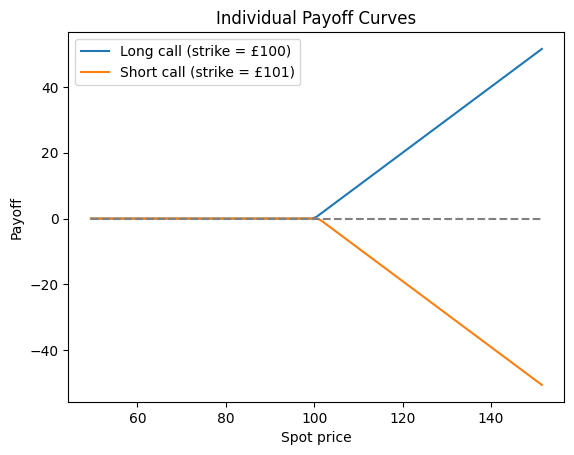

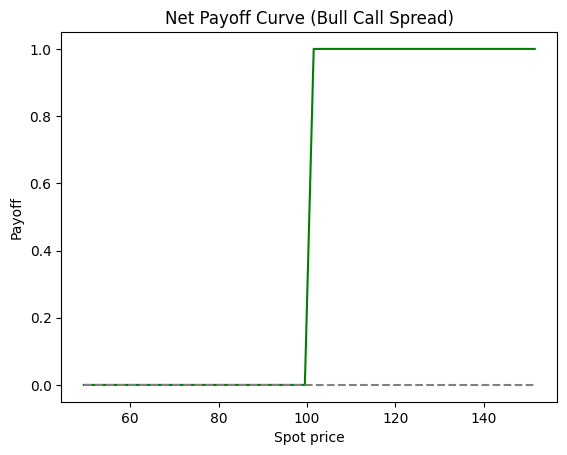

In [294]:
#build_strategy()

test_portfolio = [[True, True, 100], [False, True, 101]]

plot_strategy_payoff(test_portfolio)


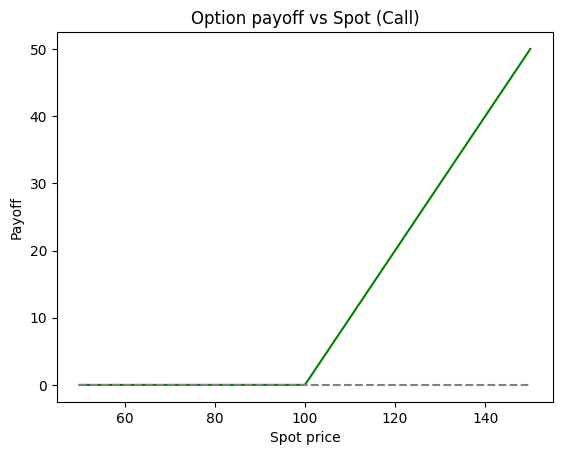

In [166]:
K = 100
vol = 0.2
T = 0.25
r = 0.05

plot_payoff(call=True, K=K, vol=vol, r=r)

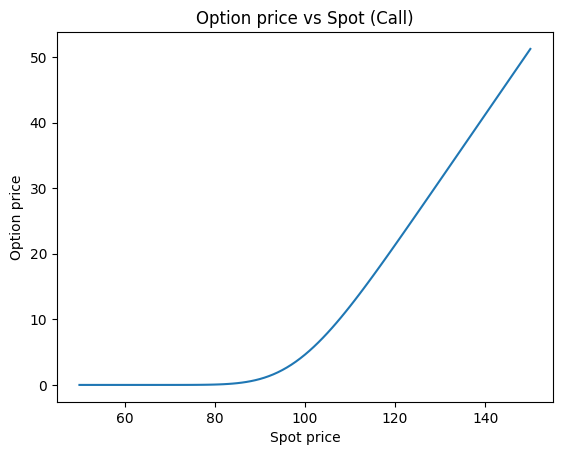

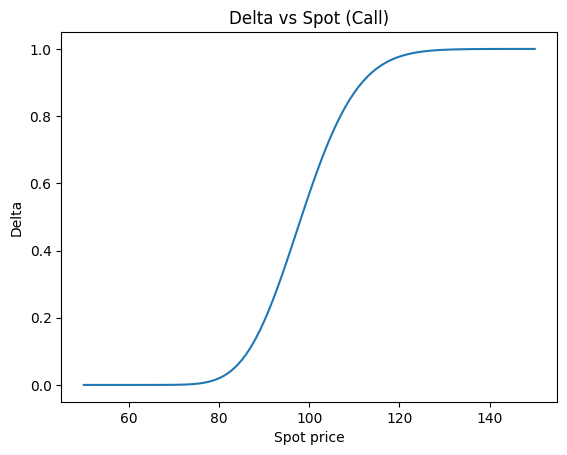

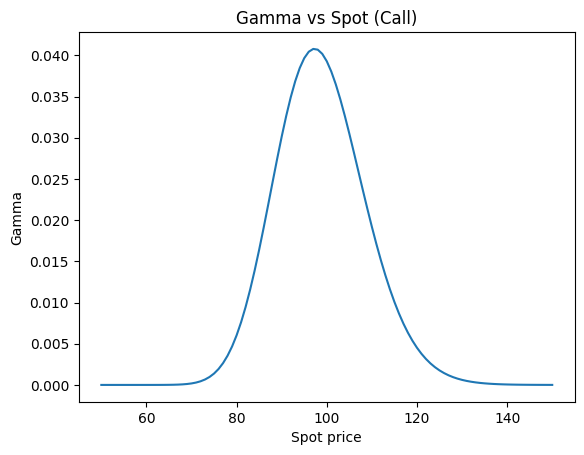

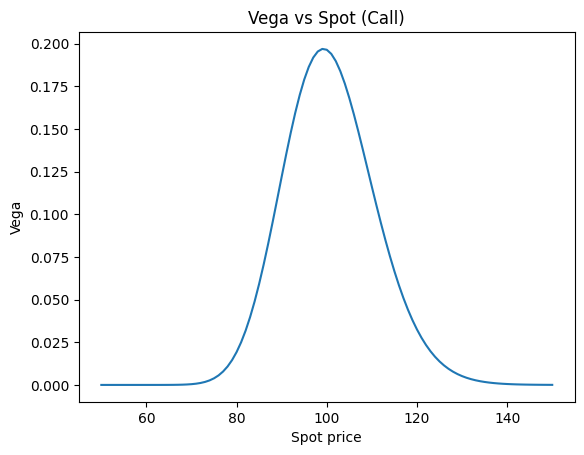

In [145]:
K = 100
vol = 0.2
T = 0.25
r = 0.05

plot_price(call=True, K=K, vol=vol, T=T, r=r)
plot_delta(call=True, K=K, vol=vol, T=T, r=r)
plot_gamma(call=True, K=K, vol=vol, T=T, r=r)
plot_vega(call=True, K=K, vol=vol, T=T, r=r)
